In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from pathlib import Path

In [12]:
RESULT_DIR = Path("../../results/dual_dp_n12_r50_e1_bs32_clip_norm10000_delta1e-05_scale_modedual_alpha0.5_beta0.5_gamma1.0_k5_epsilon_base50_epsilon_min20_lambda_protection1_nu1/")
with open(RESULT_DIR / "metrics.json", "r") as f:
    data = json.load(f)

IMAGE_DIR = Path("images") / RESULT_DIR.name
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
df = pd.DataFrame(data)
df.head()

,experiment,node,metric,round,value
0,experiment-1775481998.612593,node-4,test_loss,0,16.606825
1,experiment-1775481998.612593,node-4,test_loss,1,504.775787
2,experiment-1775481998.612593,node-4,test_loss,2,17.470890
3,experiment-1775481998.612593,node-4,test_loss,3,984.657410
4,experiment-1775481998.612593,node-4,test_loss,4,7520.813965


In [14]:
loss_df = df[df["metric"] == "test_loss"]
metric_df = df[df["metric"] == "test_metric"]

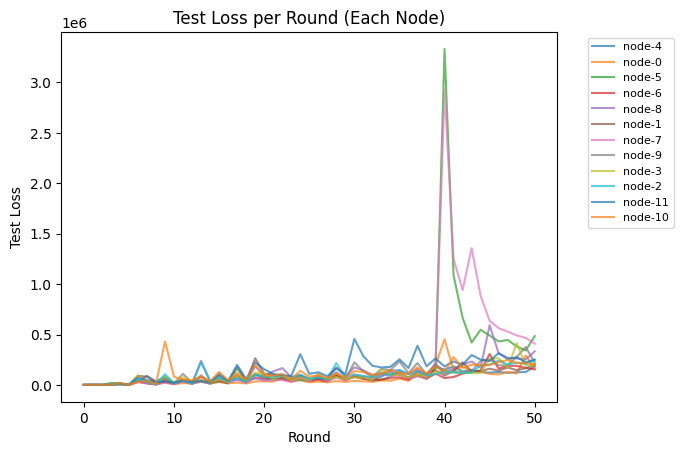

In [15]:
plt.figure()

for node in loss_df["node"].unique():
    node_data = loss_df[loss_df["node"] == node]
    plt.plot(
        node_data["round"],
        node_data["value"],
        label=f"{node}",
        alpha=0.7
    )

plt.xlabel("Round")
plt.ylabel("Test Loss")
plt.title("Test Loss per Round (Each Node)")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
# plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.savefig(IMAGE_DIR / "nodes_loss.png", bbox_inches="tight")
plt.show()

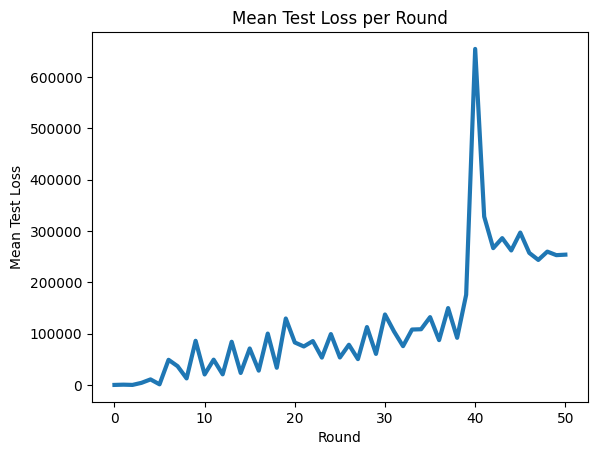

In [16]:
mean_df = (
    loss_df
    .groupby("round")["value"]
    .mean()
    .reset_index()
)

plt.figure()

plt.plot(
    mean_df["round"],
    mean_df["value"],
    linewidth=3
)

plt.xlabel("Round")
plt.ylabel("Mean Test Loss")
plt.title("Mean Test Loss per Round")
# plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.savefig(IMAGE_DIR / "mean_loss.png", bbox_inches="tight")
plt.show()

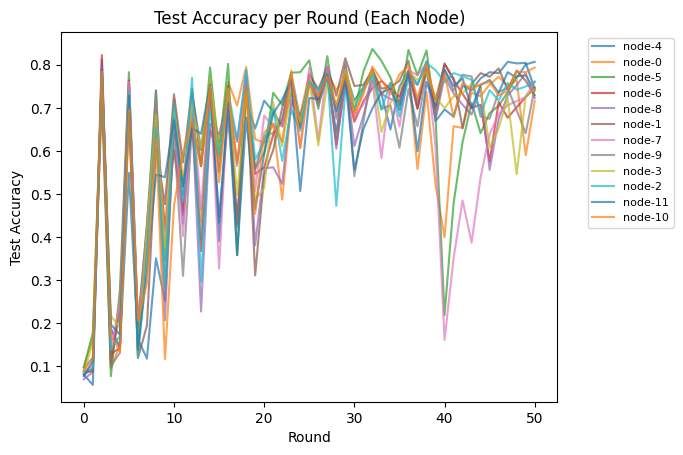

In [17]:
plt.figure()

for node in metric_df["node"].unique():
    node_data = metric_df[metric_df["node"] == node]
    plt.plot(
        node_data["round"], 
        node_data["value"],
        label=f"{node}",
        alpha=0.7
    )

plt.xlabel("Round")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy per Round (Each Node)")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
# plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.savefig(IMAGE_DIR / "nodes_accuracy.png", bbox_inches="tight")
plt.show()

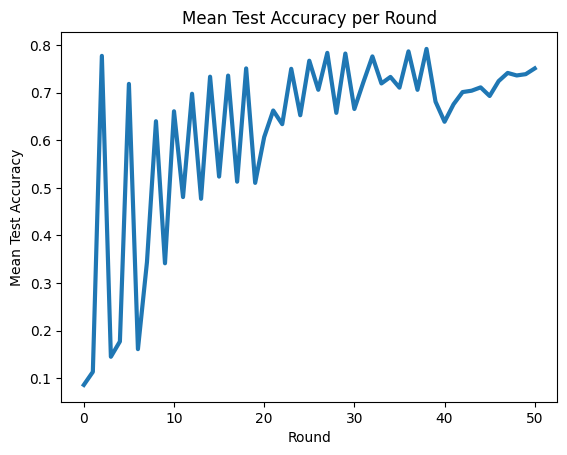

In [18]:
mean_df = (
    metric_df
    .groupby("round")["value"]
    .mean()
    .reset_index()
)

plt.figure()

plt.plot(
    mean_df["round"],
    mean_df["value"],
    linewidth=3
    # linestyle="--"
)

plt.xlabel("Round")
plt.ylabel("Mean Test Accuracy")
plt.title("Mean Test Accuracy per Round")
plt.savefig(IMAGE_DIR / "mean_accuracy.png", bbox_inches="tight")
# plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.show()